# SPEC 08 — Functional Context Proxy Analysis

**Goal**: Explore whether ER/membrane-associated annotation proxy is associated with
LIN28A-mediated translational derepression pattern.

> **Interpretation principle**: ER/membrane-associated annotation is a keyword-based
> **proxy** only. No direct ER-localized translation data is available.
> Conclusions are limited to 'functional context *may* contribute' level.

## Proxy definitions

| Proxy | Columns |
|---|---|
| `ER_membrane_core` | is_ER_or_protein_folding \| is_membrane_or_transmembrane \| is_secretory_or_extracellular \| is_Golgi_or_trafficking |
| `ER_membrane_broad` | ER_membrane_core \| is_transporter_or_channel \| is_lysosome_or_endosome |

`is_receptor_or_signaling` is reported separately (too broad for core/broad proxy).

In [1]:
%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import scipy.stats as stats
import sys

BASE  = '/home/sezero/data/BI_2026-1/Guided_Mission_1/colab-biolab/lin28a_project'
OUT_T = f'{BASE}/results/tables'
OUT_F = f'{BASE}/results/figures'

ribo_col = 'Ribosome density change (log2)'
clip_col = 'mean_CLIP_enrichment'

print(f'Python: {sys.version[:20]}')
print(f'pandas: {pd.__version__}  scipy: {__import__("scipy").__version__}')

Python: 3.10.20 (main, Mar 1
pandas: 2.3.3  scipy: 1.15.3


## 1. Master table and annotation overview

In [2]:
df = pd.read_csv(f'{OUT_T}/08_functional_context_master_table.csv')
print(f'Master table: {len(df)} rows')
print(f'\nCandidate group:')
print(df['candidate_group'].value_counts())
print(f'\nDescription null rows: {df["Description"].isna().sum()}')
print(f'  → assigned is_other_or_unclear=True')
print(f'\nEdem3 (NM_001039644) is_ER_or_protein_folding: '
      f'{df[df["Accession"]=="NM_001039644"]["is_ER_or_protein_folding"].values}')

Master table: 16465 rows

Candidate group:
candidate_group
Not_candidate      16409
A_and_B_overlap       48
A_only                 8
Name: count, dtype: int64

Description null rows: 854
  → assigned is_other_or_unclear=True

Edem3 (NM_001039644) is_ER_or_protein_folding: [ True]


In [3]:
# Proxy coverage
for proxy in ['ER_membrane_core', 'ER_membrane_broad', 'is_receptor_or_signaling']:
    n_yes = df[proxy].sum()
    print(f'{proxy}: {n_yes} / {len(df)} ({n_yes/len(df)*100:.1f}%)')
print(f'\nAnalysis subsets:')
ribo_sub = df[df[ribo_col].notna()]
s3a_sub  = df[df['dominant_binding_region'] != 'none']
main_sub = df[(df[ribo_col].notna()) & (df['dominant_binding_region'] != 'none')]
for label, sub in [('ribo_sub (ribo notna)', ribo_sub),
                   ('s3a_sub (≥1 binding site)', s3a_sub),
                   ('main_sub (s3a ∩ ribo)', main_sub)]:
    print(f'  {label}: n={len(sub)}')

ER_membrane_core: 910 / 16465 (5.5%)
ER_membrane_broad: 1606 / 16465 (9.8%)
is_receptor_or_signaling: 1595 / 16465 (9.7%)

Analysis subsets:
  ribo_sub (ribo notna): n=5701
  s3a_sub (≥1 binding site): n=6437
  main_sub (s3a ∩ ribo): n=3974


## 2. SPEC04 re-annotation verification

Re-applied SPEC04 keyword logic to all 16,465 S5 transcripts.
Verification: compare against 56-row SPEC04 annotation for candidate transcripts.

**Discrepancy**: Edem3 (NM_001039644) — `is_ER_or_protein_folding` was False in SPEC04
(keyword 'endoplasmic reticulum' does not match abbreviation 'ER' at description start).
→ Override applied manually: `is_ER_or_protein_folding = True`.

In [4]:
df04 = pd.read_csv(f'{OUT_T}/04_candidate_functional_subclass_annotation.csv')
SUBCLASS_COLS = [
    'is_ER_or_protein_folding', 'is_membrane_or_transmembrane',
    'is_secretory_or_extracellular', 'is_Golgi_or_trafficking',
    'is_lysosome_or_endosome', 'is_receptor_or_signaling',
    'is_transporter_or_channel', 'is_adhesion_or_ECM',
]
df_cand = df[df['Accession'].isin(df04['Accession'])].set_index('Accession')
disc = []
for _, r04 in df04.iterrows():
    acc = r04['Accession']
    if acc == 'NM_001039644':  # Edem3 override — expected discrepancy
        continue
    if acc not in df_cand.index:
        continue
    for sc in SUBCLASS_COLS:
        if bool(r04[sc]) != bool(df_cand.loc[acc, sc]):
            disc.append({'Accession': acc, 'Gene Symbol': r04['Gene Symbol'],
                         'subclass': sc, 'spec04': bool(r04[sc]),
                         'reapplied': bool(df_cand.loc[acc, sc])})
if disc:
    print(f'Discrepancies (excluding Edem3 override):')
    print(pd.DataFrame(disc).to_string())
else:
    print('Verification passed: 0 discrepancies (excluding Edem3 override)')

Verification passed: 0 discrepancies (excluding Edem3 override)


## 3. Analysis 1 — Ribosome density change by ER/membrane-associated annotation proxy

Subset: `ribo_sub` (transcripts with ribosome density data).
Comparison: proxy yes vs no.

> p-values from Mann-Whitney U test are **exploratory only**.
> Effect direction and n are the primary reporting metrics.

In [5]:
df_ribo_sum = pd.read_csv(f'{OUT_T}/08_ribo_change_by_er_membrane_proxy.csv')
df_ribo_sum[['proxy','group','n','median_ribo','mean_ribo','pct_positive']]

,proxy,group,n,median_ribo,mean_ribo,pct_positive
0,ER_membrane_core,yes,341,0.129197,0.076738,56.598240
1,ER_membrane_core,no,5360,-0.313768,-0.306608,28.917910
2,ER_membrane_broad,yes,486,0.145612,0.095661,58.436214
3,ER_membrane_broad,no,5215,-0.323139,-0.319030,27.976989
4,is_receptor_or_signaling,yes,417,-0.284641,-0.246259,31.654676
5,is_receptor_or_signaling,no,5284,-0.295280,-0.286632,30.488266


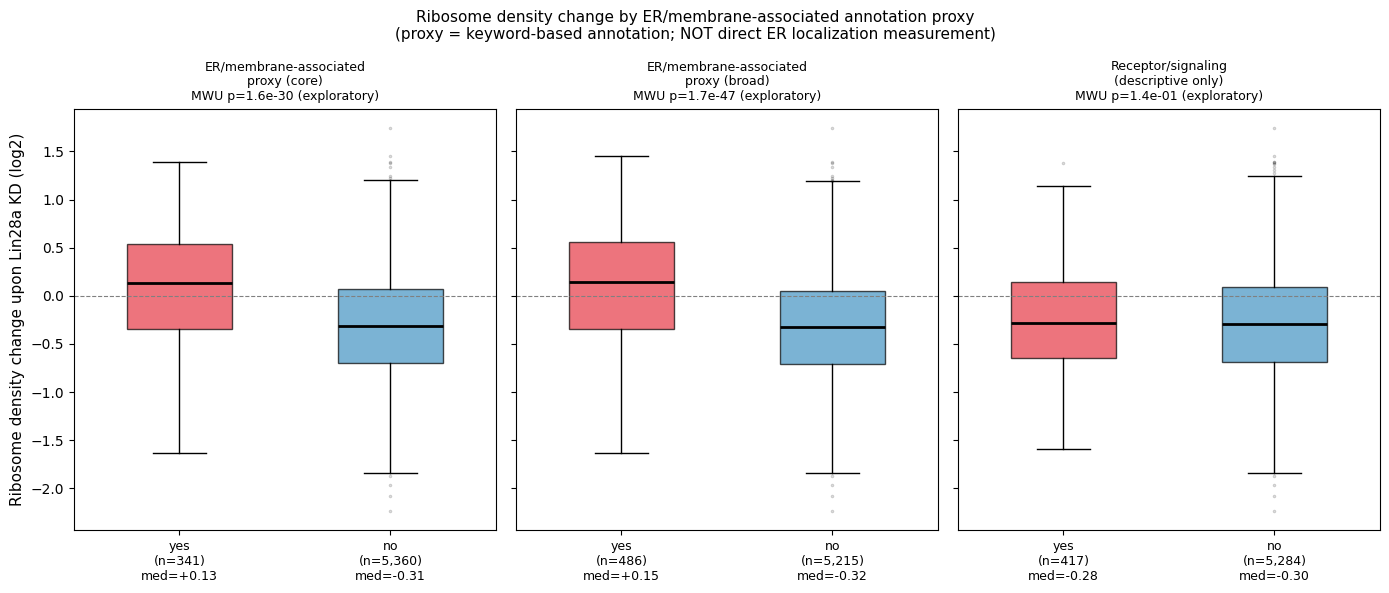

In [6]:
ribo_sub = df[df[ribo_col].notna()].copy()
PROXY_COLORS = {'yes': '#E63946', 'no': '#4393C3'}
proxy_plot = [
    ('ER_membrane_core',         'ER/membrane-associated\nproxy (core)'),
    ('ER_membrane_broad',        'ER/membrane-associated\nproxy (broad)'),
    ('is_receptor_or_signaling', 'Receptor/signaling\n(descriptive only)'),
]
fig, axes = plt.subplots(1, 3, figsize=(14, 6), sharey=True)
for ax, (proxy, title) in zip(axes, proxy_plot):
    yes_vals = ribo_sub[ribo_sub[proxy] == True][ribo_col].dropna().values
    no_vals  = ribo_sub[ribo_sub[proxy] == False][ribo_col].dropna().values
    bp = ax.boxplot([yes_vals, no_vals], positions=[0, 1], widths=0.5,
                   patch_artist=True,
                   medianprops=dict(color='black', linewidth=2),
                   flierprops=dict(marker='o', markersize=1.5, alpha=0.2))
    for patch, col in zip(bp['boxes'], ['yes', 'no']):
        patch.set(facecolor=PROXY_COLORS[col], alpha=0.7)
    ax.axhline(0, color='gray', lw=0.8, ls='--')
    _, mwu_p = stats.mannwhitneyu(yes_vals, no_vals, alternative='greater')
    ax.set_xticks([0, 1])
    ax.set_xticklabels(
        [f'yes\n(n={len(yes_vals):,})\nmed={np.median(yes_vals):+.2f}',
         f'no\n(n={len(no_vals):,})\nmed={np.median(no_vals):+.2f}'],
        fontsize=9)
    ax.set_title(f'{title}\nMWU p={mwu_p:.1e} (exploratory)', fontsize=9)
axes[0].set_ylabel('Ribosome density change upon Lin28a KD (log2)', fontsize=11)
fig.suptitle(
    'Ribosome density change by ER/membrane-associated annotation proxy\n'
    '(proxy = keyword-based annotation; NOT direct ER localization measurement)',
    fontsize=11)
fig.tight_layout()
plt.show()

## 4. Analysis 2 — High-confidence candidate fraction (two denominators)

**Denominator A (S5 total)**: all 16,465 S5 transcripts
→ co-occurrence of ER/membrane-associated annotation and HC status in full universe

**Denominator B (S3A-bound)**: transcripts with ≥1 LIN28A binding site (~6,437)
→ more directly relevant to binding-mediated effects,
but carries selection bias (S3A-bound population is already enriched for CLIP signal)

> Fisher's exact test p-values are **exploratory only**.
> n, HC fraction, effect direction are primary metrics.

In [7]:
df_hc = pd.read_csv(f'{OUT_T}/08_hc_fraction_by_er_membrane_proxy.csv')
# Format for display
df_hc['hc_pct'] = (df_hc['hc_fraction'] * 100).round(2)
df_hc[['proxy','denominator','group','n_total','n_hc','hc_pct']]

,proxy,denominator,group,n_total,n_hc,hc_pct
0,ER_membrane_core,S5_total,yes,910,16,1.76
1,ER_membrane_core,S5_total,no,15555,32,0.21
2,ER_membrane_core,S3A_bound,yes,271,11,4.06
3,ER_membrane_core,S3A_bound,no,6166,23,0.37
4,ER_membrane_broad,S5_total,yes,1606,18,1.12
5,ER_membrane_broad,S5_total,no,14859,30,0.20
6,ER_membrane_broad,S3A_bound,yes,413,12,2.91
7,ER_membrane_broad,S3A_bound,no,6024,22,0.37
8,is_receptor_or_signaling,S5_total,yes,1595,8,0.50
9,is_receptor_or_signaling,S5_total,no,14870,40,0.27


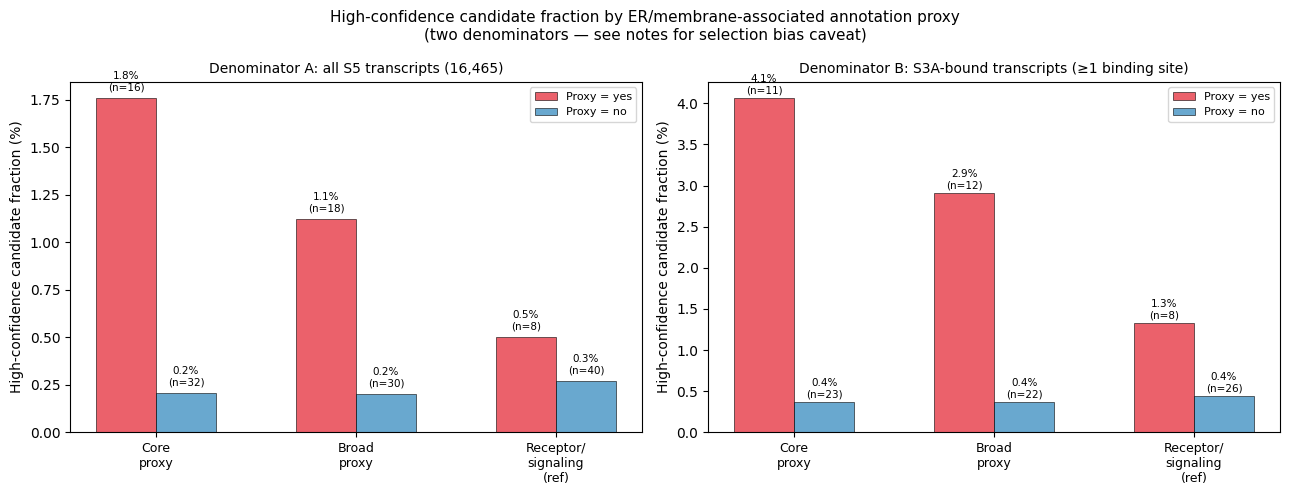

In [8]:
df_hc = pd.read_csv(f'{OUT_T}/08_hc_fraction_by_er_membrane_proxy.csv')
PROXY_COLORS = {'yes': '#E63946', 'no': '#4393C3'}
proxies_plot = ['ER_membrane_core', 'ER_membrane_broad', 'is_receptor_or_signaling']
proxy_short  = ['Core\nproxy', 'Broad\nproxy', 'Receptor/\nsignaling\n(ref)']
denom_defs   = [
    ('S5_total',  'Denominator A: all S5 transcripts (16,465)'),
    ('S3A_bound', 'Denominator B: S3A-bound transcripts (≥1 binding site)'),
]
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
bar_width = 0.3
for ax, (denom_label, title) in zip(axes, denom_defs):
    sub_df = df_hc[df_hc['denominator'] == denom_label]
    x = np.arange(len(proxies_plot))
    for j, grp in enumerate(['yes', 'no']):
        vals = []
        ns   = []
        for proxy in proxies_plot:
            row = sub_df[(sub_df['proxy'] == proxy) & (sub_df['group'] == grp)]
            vals.append(float(row['hc_fraction'].values[0]) * 100 if len(row) else 0)
            ns.append(int(row['n_hc'].values[0]) if len(row) else 0)
        bars = ax.bar(x + j * bar_width, vals, bar_width,
                      color=PROXY_COLORS[grp], alpha=0.8,
                      label=f'Proxy = {grp}',
                      edgecolor='black', linewidth=0.5)
        for bar_obj, v, n_hc in zip(bars, vals, ns):
            ax.text(bar_obj.get_x() + bar_obj.get_width() / 2,
                    bar_obj.get_height() + 0.03,
                    f'{v:.1f}%\n(n={n_hc})',
                    ha='center', va='bottom', fontsize=7.5)
    ax.set_xticks(x + bar_width / 2)
    ax.set_xticklabels(proxy_short, fontsize=9)
    ax.set_ylabel('High-confidence candidate fraction (%)', fontsize=10)
    ax.set_title(title, fontsize=10)
    ax.legend(fontsize=8)
fig.suptitle(
    'High-confidence candidate fraction by ER/membrane-associated annotation proxy\n'
    '(two denominators — see notes for selection bias caveat)',
    fontsize=11)
fig.tight_layout()
plt.show()

## 5. Analysis 3 — 2D summary: dominant binding region × ER/membrane proxy

Subset: `main_sub` (S3A-bound ∩ ribo data, n≈3,974).
Cells with n < 5 are flagged as 'n too small' and excluded from quantitative interpretation.

> Analysis unit is **transcript-level**.
> Dominant region = region with most binding sites per transcript.

In [9]:
df_2d = pd.read_csv(f'{OUT_T}/08_binding_region_by_er_membrane_proxy_summary.csv')
df_2d['median_ribo'] = df_2d['median_ribo'].round(3)
df_2d['hc_fraction'] = (df_2d['hc_fraction'] * 100).round(1)
df_2d.rename(columns={'hc_fraction': 'hc_pct'}, inplace=True)
df_2d[['dominant_binding_region','ER_membrane_core','n','median_ribo','mean_ribo','n_hc','hc_pct','note']]

,dominant_binding_region,ER_membrane_core,n,median_ribo,mean_ribo,n_hc,hc_pct,note
0,CDS,yes,114,-0.020,-0.076646,5,4.4,NaN
1,CDS,no,2698,-0.371,-0.345232,16,0.6,NaN
2,3UTR,yes,42,0.359,0.242243,6,14.3,NaN
3,3UTR,no,825,-0.164,-0.150796,7,0.8,NaN
4,5UTR,yes,0,NaN,NaN,0,NaN,n too small
5,5UTR,no,24,-0.088,-0.160058,0,0.0,NaN
6,tie,yes,11,-0.192,-0.215426,0,0.0,NaN
7,tie,no,260,-0.256,-0.279705,0,0.0,NaN


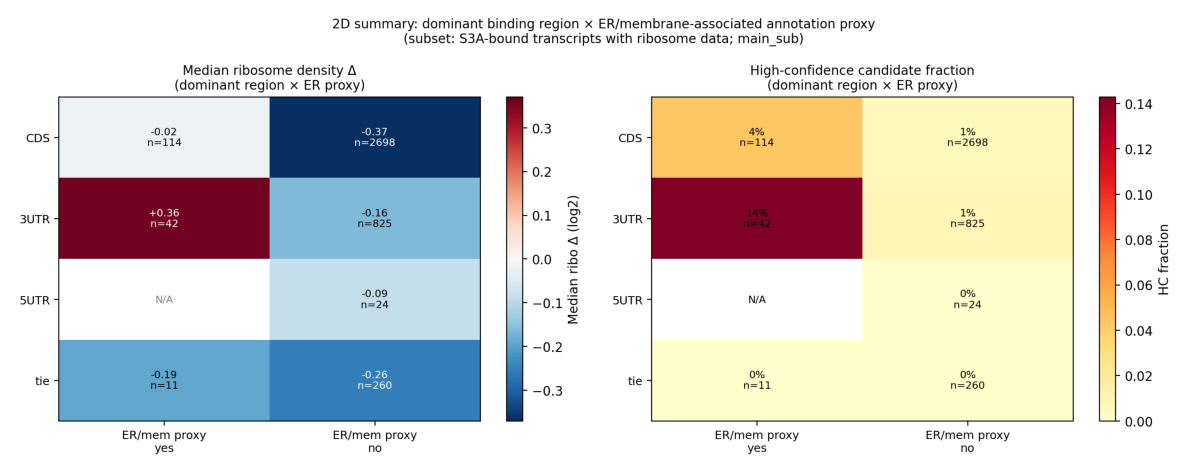

In [10]:
# Display precomputed figure
img = plt.imread(f'{OUT_F}/08_binding_region_er_proxy_interaction.png')
fig, ax = plt.subplots(figsize=(12, 5))
ax.imshow(img)
ax.axis('off')
plt.tight_layout()
plt.show()

## 6. Analysis 4 — Exploratory OLS regression

Subset: `main_sub` (S3A-bound ∩ ribo data, dominant region ∈ CDS/3′UTR/5′UTR/tie).
Reference level: dominant_binding_region = CDS.

| Predictor | Variable |
|---|---|
| CLIP enrichment | `mean_CLIP_enrichment` |
| Binding burden | `log1p(total_binding_site_count)` |
| Region (dummy) | `dom_3UTR`, `dom_5UTR`, `dom_tie` (ref=CDS) |
| ER proxy | `ER_membrane_core` (0/1) |

> **Interpretation**: coefficient direction and n are primary metrics.
> p-values are exploratory. VIF < 3 indicates acceptable collinearity.

In [11]:
df_reg = pd.read_csv(f'{OUT_T}/08_exploratory_regression_summary.csv')
# Show Model 1
print('=== Model 1 (main effects) ===')
m1 = df_reg[df_reg['model'] == 'Model1_main'][['predictor','beta','SE','p_value','ci_lo','ci_hi','note']]
print(m1.to_string(index=False))
print(f"\nR² = {df_reg[df_reg['model']=='Model1_main']['R2'].iloc[0]:.4f}")
print(f"n  = {int(df_reg[df_reg['model']=='Model1_main']['n_obs'].iloc[0])}")
print()
print('=== VIF (Model 1) ===')
vif = df_reg[df_reg['model'] == 'Model1_VIF'][['predictor','note']]
print(vif.to_string(index=False))

=== Model 1 (main effects) ===
predictor    beta     SE  p_value   ci_lo   ci_hi             note
    const  0.2259 0.0302   0.0000  0.1666  0.2851 exploratory only
     clip  0.2784 0.0079   0.0000  0.2628  0.2940 exploratory only
 log1p_bs -0.1600 0.0109   0.0000 -0.1814 -0.1386 exploratory only
 dom_3UTR  0.1543 0.0190   0.0000  0.1170  0.1916 exploratory only
 dom_5UTR  0.1635 0.1002   0.1027 -0.0329  0.3599 exploratory only
  dom_tie  0.0330 0.0316   0.2961 -0.0289  0.0949 exploratory only
  er_core  0.1640 0.0389   0.0000  0.0877  0.2402 exploratory only

R² = 0.2635
n  = 3946

=== VIF (Model 1) ===
predictor     note
     clip VIF=1.33
 log1p_bs VIF=1.36
 dom_3UTR VIF=1.03
 dom_5UTR VIF=1.01
  dom_tie VIF=1.05
  er_core VIF=1.01


In [12]:
print('=== Model 2 (+ 3UTR × ER_core interaction) ===')
m2 = df_reg[df_reg['model'] == 'Model2_3UTR_x_ercore'][['predictor','beta','SE','p_value','note']]
print(m2.to_string(index=False))
print(f"\nR² = {df_reg[df_reg['model']=='Model2_3UTR_x_ercore']['R2'].iloc[0]:.4f}")
print()
print('=== Sensitivity (include dominant=none) ===')
ms = df_reg[df_reg['model'] == 'Sensitivity_none_included'][['predictor','beta','SE','p_value','note']]
print(ms.to_string(index=False))
print(f"\nn = {int(df_reg[df_reg['model']=='Sensitivity_none_included']['n_obs'].iloc[0])}")

=== Model 2 (+ 3UTR × ER_core interaction) ===
       predictor    beta     SE  p_value             note
           const  0.2261 0.0302   0.0000 exploratory only
            clip  0.2782 0.0079   0.0000 exploratory only
        log1p_bs -0.1599 0.0109   0.0000 exploratory only
        dom_3UTR  0.1514 0.0195   0.0000 exploratory only
        dom_5UTR  0.1629 0.1002   0.1040 exploratory only
         dom_tie  0.0330 0.0316   0.2955 exploratory only
         er_core  0.1480 0.0449   0.0010 exploratory only
dom3UTR_x_ercore  0.0633 0.0891   0.4776 exploratory only

R² = 0.2636

=== Sensitivity (include dominant=none) ===
predictor    beta     SE  p_value             note
    const  0.1221 0.0277   0.0000 exploratory only
     clip  0.2327 0.0062   0.0000 exploratory only
 log1p_bs -0.1310 0.0102   0.0000 exploratory only
 dom_3UTR  0.1618 0.0194   0.0000 exploratory only
 dom_5UTR  0.1732 0.1024   0.0908 exploratory only
  dom_tie  0.0384 0.0323   0.2334 exploratory only
 dom_none -0.247

## 7. Key findings summary

### SPEC04 re-annotation

- SPEC04 keyword logic re-applied to all 16,465 S5 transcripts
- 854 rows have null Description → `is_other_or_unclear = True`
- Edem3 (NM_001039644) override applied: `is_ER_or_protein_folding = True`
- 55/56 candidates match SPEC04 (excluding Edem3 override)

### Proxy coverage

| Proxy | n | % of S5 |
|---|---|---|
| ER_membrane_core | 910 | 5.5% |
| ER_membrane_broad | 1,606 | 9.8% |
| is_receptor_or_signaling | 1,595 | 9.7% |

### Analysis 1 — Ribo change

- ER_membrane_core **yes** (n=341): median ribo Δ = **+0.129**
- ER_membrane_core **no** (n=5,360): median ribo Δ = **−0.314**
- Difference in median: Δ ≈ +0.44
- MWU p < 0.001 (exploratory; driven by large n)
- `is_receptor_or_signaling` shows no comparable enrichment (median ≈ −0.285 vs −0.295)

### Analysis 2 — HC fraction

| Denominator | Core proxy yes | Core proxy no | OR (exploratory) |
|---|---|---|---|
| S5 total | 16/910 (1.8%) | 32/15,555 (0.21%) | 8.7 |
| S3A-bound | 11/271 (4.1%) | 23/6,166 (0.37%) | 11.3 |

→ ER/membrane-associated annotation proxy transcripts are enriched for HC candidates
relative to their frequency in S5/S3A populations.

### Analysis 3 — 2D summary

- CDS-dominant × ER_core yes (n=114): median ribo = −0.020
- CDS-dominant × ER_core no (n=2,698): median ribo = −0.371
- **3′UTR-dominant × ER_core yes (n=42): median ribo = +0.359** ← strongest pattern
- 3′UTR-dominant × ER_core no (n=825): median ribo = −0.164

### Analysis 4 — Regression (Model 1)

| Predictor | β | Direction |
|---|---|---|
| mean_CLIP_enrichment | +0.28 | positive (expected) |
| log1p(binding_site_count) | −0.16 | negative (burden → not additive) |
| dom_3UTR vs CDS | +0.15 | 3′UTR sites associated with more positive ribo Δ |
| ER_membrane_core | **+0.16** | positive (functional context contributes) |
- R² = 0.26 (moderate, expected for noisy biological data)
- VIF: all < 1.5 (no multicollinearity)
- Interaction term (3′UTR × ER_core) β = +0.06, p = 0.48 (not interpretable)

### Interpretation

ER/membrane-associated annotation proxy is associated with more positive ribosome
density change upon Lin28a KD, independent of CLIP enrichment and binding site burden.
The strongest pattern is seen in 3′UTR-dominant × ER_core yes transcripts.

These results are **exploratory** and suggest that functional context **may contribute**
to the LIN28A-mediated translational derepression pattern, but direct causal inference
is not warranted. ER/membrane-associated annotation is a keyword-based proxy;
actual ER-localized translation has not been measured.

> See `notes/08_functional_context_proxy_interpretation.md` for full interpretation.